In [1]:
from sklearn.neighbors import NearestNeighbors

def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

In [5]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

num_batches = 10

Rws = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    features = []
    readouts = []

    for key in data_keys:
        batch_count = 0
        readouts.append(model.readout[key].features.detach().cpu().squeeze().T)
        
        for batch in dataloaders['train'][key]:
            batch_count += 1

            img, _, _, pupil = batch
            feature_map = model.core(img).detach().cpu()

            # grid = torch.randn(128, 1000, 1, 2) / 10
            # cropped = torch.nn.functional.grid_sample(feature_map, grid)
            # features.append(cropped.squeeze().permute(0, 2, 1).flatten(0, 1))
            
            # cropped = feature_map.permute(0, 2, 3, 1)[:, 5:-5, 15:-15, :]
            # features.append(cropped.flatten(0, 2))
            
            pred, vec = model(img, data_key=key, pupil_center=pupil)
            features.append(vec.detach().cpu().transpose(1, 3).flatten(0, 2))
            
            if batch_count == num_batches:
                break

    X = torch.cat(features)
    print(X.shape)
    Xc = X - X.mean(0, keepdim=True)
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)
    print(torch.linalg.cond(cov))

    L = torch.linalg.cholesky(cov)

    R = torch.cat(readouts)
    Rw = R @ L
    Rws.append(Rw)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([69848320, 64])
tensor(19.8532)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([69848320, 64])
tensor(20.9071)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([69848320, 64])
tensor(13.5006)


In [5]:
get_curve([100], Rws)

(array([0.43532867]), array([0.02773958]))

In [2]:
feature_maps = []
feature_vecs = []
pred_resps = []
readout_vecs = []
targets = []

for key in data_keys:
    single_maps = []
    single_vecs = []
    single_resps = []
    single_targets = []

    for batch in dataloaders['validation'][key]:
        img, target, _, pupil = batch
        single_targets.append(target)
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        single_resps.append(pred.detach().cpu())
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)
        single_vecs.append(feature_vec.detach().cpu())
        
    feature_maps.append(torch.cat(single_maps))
    feature_vecs.append(torch.cat(single_vecs))
    pred_resps.append(torch.cat(single_resps))
    readout_vecs.append(model.readout[key]._features.detach().cpu())
    targets.append(torch.cat(single_targets))

In [3]:
readouts = [r.squeeze().T for r in readout_vecs]
X = torch.cat(readouts)
Xc = X - X.mean(dim=0, keepdim=True)

_, _, Vt_readouts = torch.linalg.svd(Xc, full_matrices=False)

In [4]:
X = torch.cat([f.permute(0, 2, 3, 1).flatten(0, 2) for f in feature_vecs])
Xc = X - X.mean(dim=0, keepdim=True)

In [5]:
_, _, Vt_features = torch.linalg.svd(Xc, full_matrices=False)

In [6]:
bias = [model.readout[key].bias.detach().cpu() for key in data_keys]
pred = torch.nn.functional.elu((feature_vecs[0].squeeze(-1) * readout_vecs[0].view(1, 64, -1)).sum(1) + bias[0]) + 1
pred, pred_resps[0]

(tensor([[0.2348, 0.2744, 0.1430,  ..., 0.7161, 0.0661, 0.3129],
         [0.1937, 0.1487, 0.1222,  ..., 0.1099, 0.2656, 0.0573],
         [0.2332, 0.6409, 0.1813,  ..., 0.4390, 0.6676, 0.9979],
         ...,
         [0.2468, 0.3823, 0.3247,  ..., 0.7784, 0.3982, 0.0815],
         [0.3634, 0.4632, 0.3763,  ..., 0.5492, 0.3057, 0.1517],
         [0.3974, 0.8986, 0.6134,  ..., 0.3683, 1.1256, 0.9109]]),
 tensor([[0.2348, 0.2744, 0.1430,  ..., 0.7161, 0.0661, 0.3129],
         [0.1937, 0.1487, 0.1222,  ..., 0.1099, 0.2656, 0.0573],
         [0.2332, 0.6409, 0.1813,  ..., 0.4390, 0.6676, 0.9979],
         ...,
         [0.2468, 0.3823, 0.3247,  ..., 0.7784, 0.3982, 0.0815],
         [0.3634, 0.4632, 0.3763,  ..., 0.5492, 0.3057, 0.1517],
         [0.3974, 0.8986, 0.6134,  ..., 0.3683, 1.1256, 0.9109]]))

In [8]:
vars = torch.stack([targets[5].flatten().cpu(), pred_resps[5].flatten()])
torch.corrcoef(vars)[0, 1]

tensor(0.4695)

In [21]:
targets = [t.cpu().flatten() for t in targets]

In [5]:
features = [f.squeeze(-1).transpose(1, 2) for f in feature_vecs]
readouts = [r.view(1, 64, -1).transpose(1, 2) for r in readout_vecs]

In [13]:
#ds = list(range(1, 65))
ds = [16, 24, 32, 40, 48, 56, 64]
correlations_readouts = []
correlations_features = []

for d in ds:
    print(d) if d % 8 == 0 else None

    features_compressed = [f @ Vt_readouts[:d].T @ Vt_readouts[:d] for f in features]
    compressed_preds = [torch.nn.functional.elu((f * r).sum(dim=2) + b) + 1 for f, r, b in zip(features_compressed, readouts, bias)]

    vars = [torch.stack([t.flatten().cpu(), c.flatten()]) for t, c in zip(targets, compressed_preds)]

    correlations_readouts.append(torch.tensor([torch.corrcoef(v)[0, 1] for v in vars]).mean())

    features_compressed = [f @ Vt_features[:d].T @ Vt_features[:d] for f in features]
    compressed_preds = [torch.nn.functional.elu((f * r).sum(dim=2) + b) + 1 for f, r, b in zip(features_compressed, readouts, bias)]

    vars = [torch.stack([t.flatten().cpu(), c.flatten()]) for t, c in zip(targets, compressed_preds)]

    correlations_features.append(torch.tensor([torch.corrcoef(v)[0, 1] for v in vars]).mean())

16
24
32
40
48
56
64


In [15]:
correlations_readouts

[tensor(0.2956),
 tensor(0.3341),
 tensor(0.3622),
 tensor(0.3774),
 tensor(0.3877),
 tensor(0.3955),
 tensor(0.4142)]

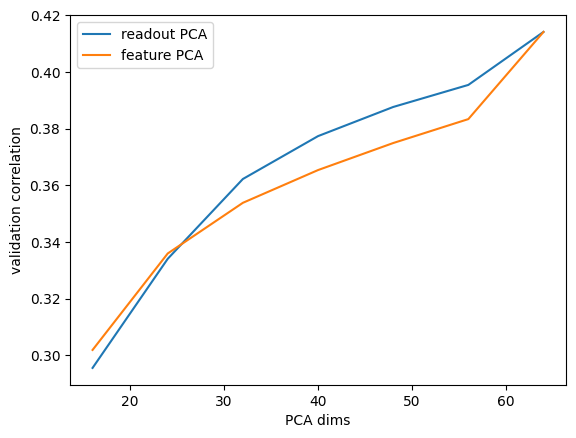

In [14]:
plt.plot(ds, correlations_readouts, label='readout PCA')
plt.plot(ds, correlations_features, label='feature PCA')
plt.xlabel('PCA dims')
plt.ylabel('validation correlation')
plt.legend()

In [6]:
X = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

# compute cov
mu = X.mean(dim=0, keepdims=True)
Xc = X - mu
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

# get whitening matrix from cov
L = torch.linalg.cholesky(cov)
Winv = L.T
W = Winv.inverse()

# whiten channels
C = feature_vecs[0].squeeze().permute(2, 0, 1)
Cc = C - mu
Cw = Cc @ W

Cwf = Cw.flatten(0, 1)
cov_w = Cwf.T @ Cwf / (Cwf.shape[0] - 1)
print('whitened cov max deviation from identity:', (cov_w - torch.eye(64)).abs().max())

# compute corresponding readout vecs
R = readout_vecs[0].squeeze().T.unsqueeze(2)
Rw = Winv @ R

# compare results

print((Cw @ Rw + mu @ R).squeeze())
print((C @ R).squeeze())

whitened cov max deviation from identity: tensor(1.4428)
tensor([[-1.1575, -1.5698, -0.8308,  ..., -1.2370, -0.7365, -0.5814],
        [-0.8863, -2.1010, -0.7356,  ..., -0.5522, -0.7772, -0.1974],
        [-1.4602, -1.5866, -1.2578,  ..., -0.3216, -0.3040, -0.2590],
        ...,
        [-0.4943, -1.9880, -0.1564,  ..., -0.5192, -0.2120, -1.3359],
        [-0.7835, -0.3859,  0.3939,  ..., -0.7369, -0.3749,  0.4941],
        [-1.2482, -2.6734,  1.1068,  ..., -1.6682, -1.6188, -1.0610]])
tensor([[-1.1575, -1.5698, -0.8308,  ..., -1.2370, -0.7365, -0.5814],
        [-0.8863, -2.1010, -0.7356,  ..., -0.5522, -0.7772, -0.1974],
        [-1.4602, -1.5866, -1.2578,  ..., -0.3216, -0.3040, -0.2590],
        ...,
        [-0.4943, -1.9880, -0.1564,  ..., -0.5192, -0.2120, -1.3359],
        [-0.7835, -0.3859,  0.3939,  ..., -0.7369, -0.3749,  0.4941],
        [-1.2482, -2.6734,  1.1068,  ..., -1.6682, -1.6188, -1.0610]])


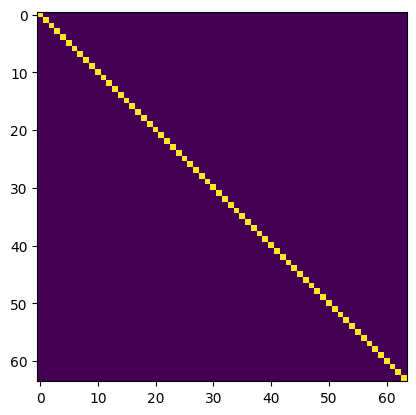

In [6]:
Xw = (X - mu) @ W
plt.imshow(Xw.T @ Xw / (Xw.shape[0] - 1))

In [8]:
R = torch.cat([r.squeeze() for r in readout_vecs], dim=1)
Rw = R.T @ Winv.T

In [10]:
R.shape

torch.Size([64, 54569])

In [8]:
i, j = torch.tril_indices(64, 64, offset=-1)
data = cov_w[i, j]

In [39]:
cov = (Cwf.T @ Cwf) / (Cwf.shape[0] - 1)
std = Cwf.std(dim=0, keepdim=True)
corr = cov / (std.T @ std)

In [43]:
i, j = torch.tril_indices(64, 64, offset=-1)
offdiag = corr[i, j]

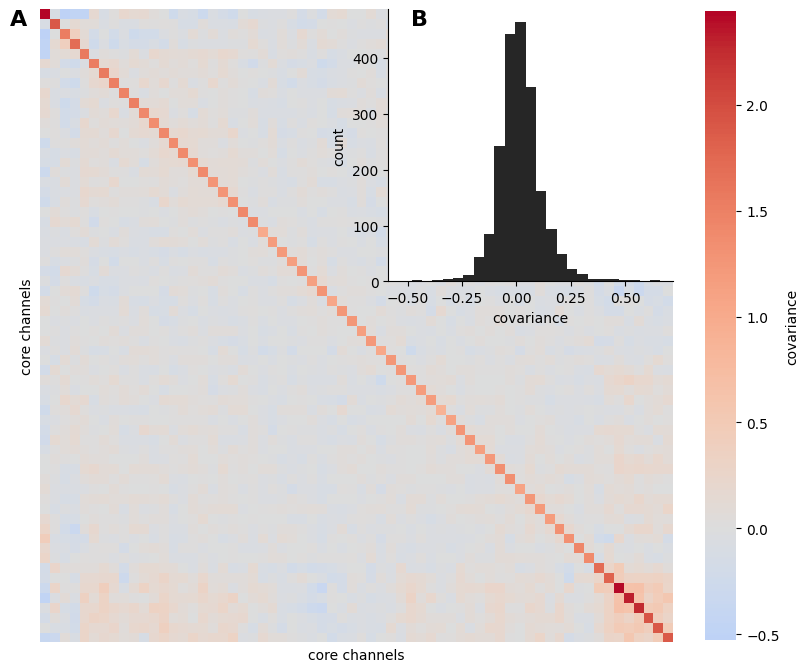

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Assuming corr is already defined (your correlation matrix)

# Create figure with just one plot
fig, ax = plt.subplots(1, 1, figsize=(8, 7.1), constrained_layout=True)

# --- Correlation heatmap ---
data = cov_w
clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind
plt.close(clustermap.fig)
data = data[order][:, order]

hm = sns.heatmap(
    data,
    ax=ax,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 0.9},
    xticklabels=False,
    yticklabels=False,
)
ax.set_xlabel("core channels")
ax.set_ylabel("core channels")
hm.figure.axes[-1].set_ylabel("covariance")
ax.text(-0.02, 1, 'A', transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='right')

# --- Inset histogram (top-right overlay) ---
# get lower-triangular correlations (exclude diagonal)
data_np = np.asarray(data)
i, j = np.tril_indices(data_np.shape[0], k=-1)
corr_values = data_np[i, j]

axins = inset_axes(ax, width="45%", height="43%", loc="upper right", borderpad=0)
axins.hist(corr_values, bins=25, color="black", alpha=0.85)
axins.text(0.14, 1, 'B', transform=axins.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='right')
axins.set_xlabel('covariance')
axins.set_ylabel('count')
#axins.set_xticks([-0.2, 0, 0.2, 0.4])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

# Save and show
plt.savefig('plots/results_whitened_vecs.pdf')
plt.show()

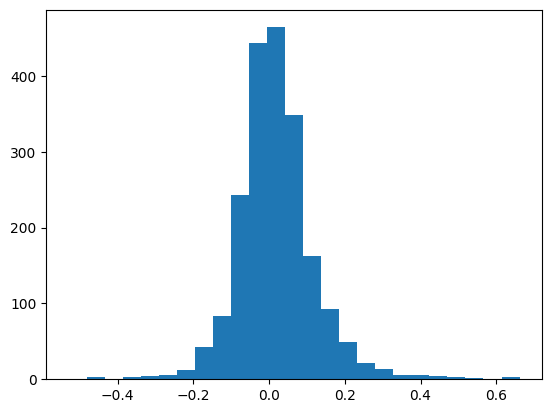

In [10]:
plt.hist(data, bins=25)
plt.show()

In [22]:
from sklearn.neighbors import NearestNeighbors

In [23]:
def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [24]:
def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    curve = np.zeros(len(k_range))
    for x, y in zip(x_idcs, y_idcs):
        curve += knn_consistency(knns[x], knns[y], ks=k_range) 
    
    curve /= len(x_idcs)

    return curve

In [25]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curve = get_curve(k_range, [Rw])

/tmp/ipykernel_3234222/1207887741.py:14: RuntimeWarning: invalid value encountered in divide
  curve /= len(x_idcs)


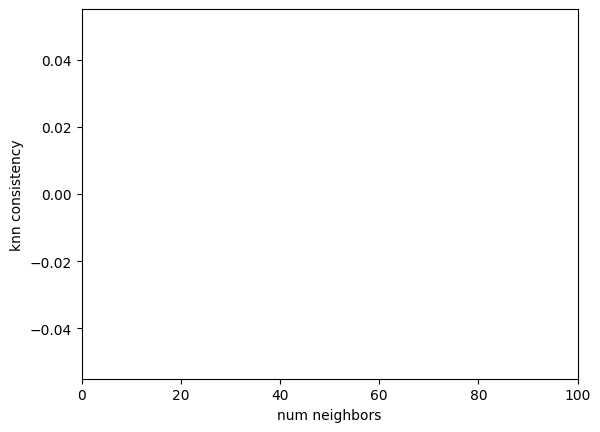

In [26]:
plt.plot(k_range, curve, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn consistency')
plt.xlim(0, 100)
plt.show()